
# LLM Router — Unified Log Loader
This notebook loads and indexes experiment runs with the unified filenames:
- `metrics.jsonl`
- `output.jsonl`
- `queue.json` (optional)
- `results.json`

It assumes your repo layout like:
```
results/
  rr-batching/
    17/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
  pull-batching/
    29/
      metrics.jsonl
      output.jsonl
      queue.json
      results.json
...
```

> **Tip:** You can change `BASE_DIR` below if your results are elsewhere.


In [25]:
import pandas as pd

from utils_analysis import (
    make_runs_index,
    load_experiment,
    normalize_metrics_samples,
    collect_results_summary,
    collect_all_metrics,
    collect_all_outputs,
    select_metrics,
    metrics_to_endpoint_tables,
    summarize_output_metric,
    draw_output_time_each,
    summarize_metrics_metric,
    summarize_queue_metric,
    cumulative_output_metric,
    cumulative_metrics_metric,
    cumulative_queue_metric,
    list_available_metrics_metrics,
    list_available_output_metrics,
    list_all_metrics_for_run,
    draw_violin_for_metric,
)


BASE_DIR = "/home/saeid/llm-lb/results"  # or "results copy"
SERIES = "134"

# Put only the experiments you want to analyze here:
EXPERIMENTS = [
    # ("rr-batching", "17"),
    # ("rr-batching", "18"),
    ("rr-batching", SERIES),
    # ("least-queue-batching", SERIES),
    # ("pull-batching", SERIES),
    # ("least-queue-batching", "6"),
    # ("random-batching", "5"),
    # ("pull", "5"),
    # ("least-queue-worker", "2"),
    # ("pull-batching", "40"),
    # ("least-queue-batching", "14"),
]

runs_index = make_runs_index(EXPERIMENTS, base_dir=BASE_DIR)
# runs_index

In [26]:
results_summary = collect_results_summary(runs_index)
metrics_all = collect_all_metrics(runs_index)
outputs_all = collect_all_outputs(runs_index)

# display(results_summary.head())
# display(metrics_all.head())
# display(outputs_all.head())

# Optional CSVs for quick offline inspection
# runs_index.to_csv("runs_index.csv", index=False)
# if not results_summary.empty:
#     results_summary.to_csv("results_summary_flat.csv", index=False)
# print("Exports written where available")
# outputs_all


=== Count of Short/Long Requests per Endpoint ===
endpoint  http://127.0.0.1:9101  http://127.0.0.1:9102
req_type                                              
long                          4                      3
short                         1                      2

=== Totals across endpoints ===
req_type
long     7
short    3
dtype: int64


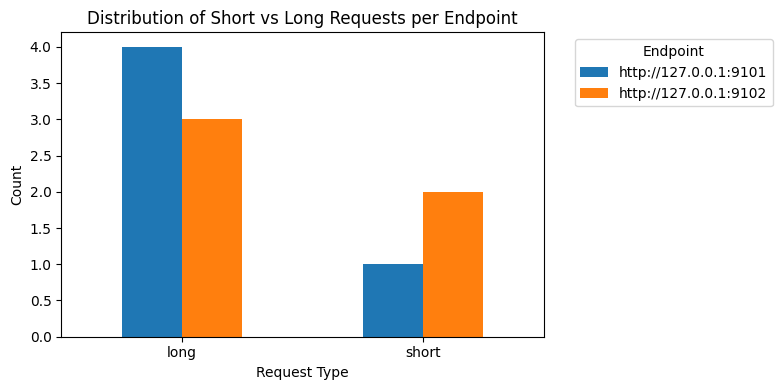

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the threshold (match your config)
THRESHOLD = 33  # or whatever threshold you used for short vs long

# Classify short vs. long requests
outputs_all["req_type"] = outputs_all["predicted_out_tokens"].apply(
    lambda x: "short" if pd.notnull(x) and x <= THRESHOLD else "long"
)

# Aggregate counts by request type and endpoint
dist = outputs_all.groupby(["req_type", "endpoint"]).size().unstack(fill_value=0)

# Print numeric table
print("\n=== Count of Short/Long Requests per Endpoint ===")
print(dist)
print("\n=== Totals across endpoints ===")
print(dist.sum(axis=1))

# Plot grouped bars (short vs long on x-axis, endpoints as columns)
dist.plot(kind="bar", figsize=(8, 4))
plt.title("Distribution of Short vs Long Requests per Endpoint")
plt.xlabel("Request Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Endpoint", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
